<a href="https://colab.research.google.com/github/Zinniacodes01/Zinnia-s-Code/blob/main/Tensorflow_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url='https://storage.googleapis.com/download.tensorflow.org/data/abalone_train.csv'
columns=['Sex',
'Length',
'Diameter',
'Height',
'Whole weight',
'Shucked weight',
'Viscera weight',
'Shell weight',
'Age of abalone']

# FIX 1: Correctly read the CSV. The file is tab-separated, and pandas can infer this.
# Removed sep=' ' and comment='\t' to allow pandas to infer the tab separator.
df = pd.read_csv(url, names=columns, na_values='?')
print('DataFrame before dropping NaNs:')
print(df.head())
print('Shape before dropping NaNs:', df.shape)
df.dropna(inplace=True,axis=0)
print('DataFrame after dropping NaNs:')
print(df.head())
print('Shape after dropping NaNs:', df.shape)

# FIX 2: One-hot encode the 'Sex' categorical column.
df = pd.get_dummies(df, columns=['Sex'], prefix='Sex')

train_dataset = df.sample(frac=0.8, random_state=42)
test_dataset = df.drop(train_dataset.index)

xtrain=train_dataset.drop('Age of abalone',axis=1)
ytrain=train_dataset['Age of abalone']
xtest=test_dataset.drop('Age of abalone',axis=1)
ytest=test_dataset['Age of abalone']

train_dataset.describe()

normalizer=tf.keras.layers.Normalization(axis=-1)
# Ensure xtrain is numerical. After get_dummies, it should be.
xtrain=np.array(xtrain, dtype=np.float32) # Explicitly cast to float32
# FIX 3: Removed +1 from normalizer.adapt. It's not a standard preprocessing step.
normalizer.adapt(xtrain)

model=tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(1)
])#<-dense neural network
model.compile(loss='mean_absolute_error',optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
history=model.fit(xtrain,ytrain,epochs=100,validation_split=0.2)# validation is IMPORTANT
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.xlabel('epochs')
plt.legend()
plt.show()

test_loss=model.evaluate(xtest,ytest)

# FIX 4: The prediction input shape needs to match the model's input shape.
# After one-hot encoding 'Sex', the input features will be 7 original numerical + 3 for Sex (Sex_F, Sex_I, Sex_M) = 10 features.
# Creating a sample input with 10 features for prediction:
# Assuming order: Length, Diameter, Height, Whole weight, Shucked weight, Viscera weight, Shell weight, Sex_F, Sex_I, Sex_M
sample_prediction_input = np.array([[0.5, 0.4, 0.15, 0.8, 0.3, 0.2, 0.25, 0, 0, 1]]) # Example values for a male abalone
y_predict=model.predict(sample_prediction_input)
print("Single prediction example:", y_predict)


# FIX 5: Corrected the loop for predictions to iterate through test samples and print actual vs predicted for a regression model.
print("\nPredictions for first 25 test samples:")
for n in range(25):
  sample_features = xtest.iloc[n:n+1] # Get one row from DataFrame
  actual_age = ytest.iloc[n]
  # Predict, get scalar result (using verbose=0 to suppress output for each prediction)
  prediction = model.predict(np.array(sample_features, dtype=np.float32), verbose=0)[0][0]

  print(f"Sample {n+1}: Predicted Age = {prediction:.2f}, Actual Age = {actual_age}")

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:4008: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:207: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


ValueError: Training data contains 0 samples, which is not sufficient to split it into a validation and training set as specified by `validation_split=0.2`. Either provide more data, or a different value for the `validation_split` argument.

In [ ]:
fashion_mnist=tf.keras.datasets.fashion_mnist
(trainimages,trainlabels),(testimages,testlabels)=fashion_mnist.load_data()

In [ ]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print(trainlabels.shape,trainimages.shape)
print(testlabels.shape,testimages.shape)#already preprocessed

In [ ]:
plt.imshow(trainimages[4756])
plt.title(class_names[trainlabels[4756]])

In [ ]:
trainimages=trainimages/255
testimages=testimages/255

In [ ]:
plt.figure(figsize=(25,25))
for n in range(25):
  plt.xlabel(class_names[trainlabels[n]])
  plt.subplot(5,5,n+1)
  plt.imshow(trainimages[n])

In [ ]:
# @title
model=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),#RULE: data needs to be 1d array before using dense layer
    tf.keras.layers.Dense(128,activation='relu'),# relu is IMPORTANT(Rectified Linear Unit,f(x)= if x>0: f(x)=x if x<=0: f(x)=0)
#    tf.keras.layers.Dense(128,activation='relu'),#experiment: does adding layers or making numers bigger(binary only) do better
 #   tf.keras.layers.Dense(128,activation='relu'),#more layers  or more nodes does not mean more accuracy!
  #  tf.keras.layers.Dense(128,activation='relu'),
   # tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(10),#RULE:
])

In [ ]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),optimizer='adam',metrics=['accuracy'])
#whenever there are multiple classes, we go with SparseCategoricalCrossentropy

In [ ]:
history=model.fit(trainimages,trainlabels,epochs=10,validation_split=0.2)

In [ ]:
model.evaluate(testimages,testlabels)

In [ ]:
plt.figure(figsize=(100,100))
probability_model=tf.keras.Sequential([
    model,
    tf.keras.layers.Softmax()
])#converts it into a probablitity model
for n in range(100):
  image=testimages[n]
  plt.subplot(50,2,n+1)
  plt.imshow(image)
  image=np.expand_dims(image,0)#also important so that it adds a dimension to the image to convert from (28,28) to (1,28,28)
  predictions=probability_model.predict(image)
  category=np.argmax(predictions[0])#identify max value in array and return index
  plt.xlabel("Predicted: "+class_names[category])
  plt.ylabel(" Actual: "+class_names[testlabels[n]])

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=tf.keras.datasets.mnist
(train_images,train_labels),(test_images,test_labels)=df.load_data()
plt.figure(figsize=(100,100))
train_images=train_images/255
test_images=test_images/255
print(test_images.shape)
model=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(32,32,3)),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(loss='sparse_categorical_crossentropy',optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy'])
#model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),optimizer='adam',metrics=['accuracy'])
history=model.fit(train_images,train_labels, epochs=10,validation_split=0.2)
test_loss,test_accuracy=model.evaluate(test_images,test_labels)
print("Test Loss: ",test_loss)
print("Test Accuracy: ",test_accuracy)
plt.figure(figsize=(40,40))
for n in range(25):
  plt.subplot(5,5,n+1)
  plt.imshow(test_images[n])
  sample_image=test_images[n]
  sample_image=np.expand_dims(sample_image,0)
  predictions=model.predict(sample_image)
  predicted_class=np.argmax(predictions[0])#identifies the index of the highest value
  print(test_labels[n])
  plt.ylabel("Actual: "+str(columnnames[test_labels[n][0]]))
  plt.xlabel('Predicted: '+str(columnnames[predicted_class]))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 28, 28), dtype=float32). Expected shape (None, 32, 32, 3), but input has incompatible shape (32, 28, 28)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 28, 28), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

<Figure size 10000x10000 with 0 Axes>

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3568 - loss: 2.5748 - val_accuracy: 0.1004 - val_loss: 2.3005
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1009 - loss: 2.3029 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0966 - loss: 2.3026 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0980 - loss: 2.3026 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0983 - loss: 2.3026 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.0982 - loss: 2.3026 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0984 - loss: 2.3026 - val_accuracy: 0.0995 - val_loss: 2.3026
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.0979 - loss: 2.3026 - 

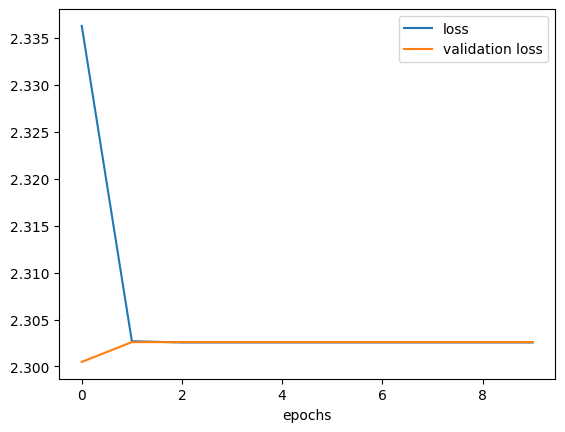

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=tf.keras.datasets.mnist
print(df)
(train_images,train_labels),(test_images,test_labels)=df.load_data()
xtrain=train_images.reshape(train_images.shape[0],-1)
xtest=test_images.reshape(test_images.shape[0],-1)
normalizer=tf.keras.layers.Normalization(axis=-1)
normalizer.adapt(xtrain)
model=tf.keras.Sequential([
    normalizer,
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='relu')
])
model.compile(loss='sparse_categorical_crossentropy',optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),metrics=['accuracy'])
history=model.fit(xtrain, train_labels,epochs=10,validation_split=0.2)
plt.plot(history.history['loss'],label='loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.xlabel('epochs')
plt.legend()
test_loss,test_accuracy=model.evaluate(xtest, test_labels)
print("Loss: ",test_loss)
print("Accuracy: ",test_accuracy)
# for n in range(25):
#   plt.subplot(5,5,n+1)
#   plt.imshow(test_images[n])
#   sample_image=test_images[n]
#   sample_image=np.expand_dims(sample_image,0)
#   predictions=model.predict(sample_image)
#   predicted_class=np.argmax(predictions[0])#identifies the index of the highest value
#   print(test_labels[n])
#   # plt.ylabel("Actual: "+str(columnnames[test_labels[n][0]]))
#   # plt.xlabel('Predicted: '+str(columnnames[predicted_class]))
# sample_image=xtest[0:1]
# predictions=model.predict(tf.constant(sample_image))
# predicted_class=np.argmax(predictions[0])
# print("Predicted: ",predicted_class)
# print(f"Actual: ",test_labels[0])

In [ ]:
model.save('numbermnist.keras')

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=tf.keras.datasets.mnist
(train_images,train_labels),(test_images,test_labels)=df.load_data()
plt.figure(figsize=(25,25))
train_images=train_images/255
test_images=test_images/255
print(test_images.shape)
model=tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])
model.compile(loss='sparse_categorical_crossentropy',optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy'])
#model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),optimizer='adam',metrics=['accuracy'])
history=model.fit(train_images,train_labels, epochs=10,validation_split=0.2)
test_loss,test_accuracy=model.evaluate(test_images,test_labels)
print("Test Loss: ",test_loss)
print("Test Accuracy: ",test_accuracy)
plt.figure(figsize=(40,40))
for n in range(25):
  plt.subplot(5,5,n+1)
  plt.imshow(test_images[n])
  sample_image=test_images[n]
  sample_image=np.expand_dims(sample_image,0)
  predictions=model.predict(sample_image)
  predicted_class=np.argmax(predictions[0])#identifies the index of the highest value
  print(test_labels[n])
  plt.ylabel("Actual: "+str(test_labels[n]))
  plt.xlabel('Predicted: '+str(predicted_class))

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
url='https://storage.googleapis.com/download.tensorflow.org/data/abalone_train.csv'
columns=[
'Length',
'Diameter',
'Height',
'Whole weight',
'Shucked weight',
'Viscera weight',
'Shell weight',
'Age of abalone']
df = pd.read_csv(url, names=columns)
train_dataset = df.sample(frac=0.8, random_state=42)
test_dataset = df.drop(train_dataset.index)
xtrain=train_dataset.drop('Age of abalone',axis=1)
ytrain=train_dataset['Age of abalone']
xtest=test_dataset.drop('Age of abalone',axis=1)
ytest=test_dataset['Age of abalone']
print(ytest.shape)
xtrain=np.array(xtrain)
ytest=np.array(ytest)
model=tf.keras.Sequential([
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(1)
])#<-dense neural network
model.compile(loss='mean_absolute_error',optimizer=tf.keras.optimizers.Adam(learning_rate=0.001))
history=model.fit(xtrain,ytrain,epochs=10,validation_split=0.2)# validation is IMPORTANT
for n in range(25):
  sample_values=xtest[n:n+1]
  prediction=model.predict(sample_values)
  print("Predicted: ",prediction)
  print("Actual: ",ytest[n])

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=tf.keras.datasets
(train_images, train_labels), (test_images, test_labels) = df.cifar10.load_data()
class_names=['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(100,100))
train_images=train_images/255
test_images=test_images/255
print(test_images.shape)
cnnmodel=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax'),#because 10 classes
])
cnnmodel.compile(loss='sparse_categorical_crossentropy',optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy'])
history=cnnmodel.fit(train_images,train_labels, epochs=10,validation_split=0.2)
test_loss,test_accuracy=cnnmodel.evaluate(test_images,test_labels)
print("Test Loss: ",test_loss)
print("Test Accuracy: ",test_accuracy)
plt.figure(figsize=(40,40))
for n in range(20):
  plt.subplot(5,5,n+1)
  plt.imshow(test_images[n])
  sample_image=test_images[n]
  sample_image=np.expand_dims(sample_image,0)
  predictions=cnnmodel.predict(sample_image)
  predicted_class=np.argmax(predictions[0])#identifies the index of the highest value
  print(test_labels[n])
  plt.ylabel("Actual: "+str(class_names[test_labels[n][0]]))
  plt.xlabel('Predicted: '+str(class_names[predicted_class]))

In [ ]:
imgs=['dog_1.jpeg','frog_1.jpeg','horse_1.jpeg','ship_1.jpeg','truck_1.jpeg',]
img_labels=['dog','frog','horse','ship','truck']
plt.figure(figsize=(12,12))
for n in imgs:
  plt.subplot(3,2,imgs.index(n)+1)
  current_img=tf.keras.utils.load_img(n, target_size=(32,32))
  plt.imshow(current_img)
  current_imgarray=tf.keras.utils.img_to_array(current_img)/255
  new_img=np.expand_dims(current_imgarray,0)#actually do need expand_dims
  predictions=cnnmodel.predict(new_img)
  type_of_img=np.argmax(predictions[0])
  plt.xlabel('Predicted: '+str(class_names[type_of_img]))
  plt.ylabel('Actual: '+str(img_labels[imgs.index(n)]))

In [ ]:
import tensorflow_datasets as tfds
dataset=tfds.load("cats_vs_dogs",split="train", as_supervised=True)

Start here

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
(train_dataset, test_dataset)=tfds.load("cats_vs_dogs",split=['train[:80%]','train[80%:]'],as_supervised=True,)
class_names=['Cat','Dog']
print(train_dataset)

In [ ]:
plt.figure(figsize=(20,20))
n=0
for image,label in test_dataset.take(9):
  plt.subplot(3,3,n+1)
  plt.imshow(image.numpy().astype("uint"))
  plt.title(int(label))
  n+=1

In [ ]:
def resized(img,label):
  resized_img=tf.image.resize(img,(150,150))
  return resized_img, label
test_dataset=test_dataset.map(lambda image,label:resized(image,label))
train_dataset=train_dataset.map(lambda image,label:resized(image,label))
train_dataset=train_dataset.cache().batch(32).prefetch(buffer_size=10)
test_dataset=test_dataset.cache().batch(32).prefetch(buffer_size=10)

In [ ]:
cnnmodel=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(2,activation='softmax'),])
cnnmodel.compile(loss='binary_crossentropy',optimizer=tf.keras.optimizers.Adam(),metrics=['binary_accuracy'])#because 2 classes
history=cnnmodel.fit(train_dataset,epochs=10)

In [ ]:
cnnmodel.summary()

In [ ]:

training_images=np.array(training_images)
training_images=training_images/255
test_images=np.array(test_images)
test_images=test_images/255
cnnmodel=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(2,activation='softmax'),])
cnnmodel.compile(loss='sparse_categorical_crossentropy',optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy'])
history=cnnmodel.fit(training_images,training_labels, epochs=10,validation_split=0.2)
test_loss,test_accuracy=cnnmodel.evaluate(test_images,test_labels)
print("Test Loss: ",test_loss)
print("Test Accuracy: ",test_accuracy)
plt.figure(figsize=(40,40))
for n in range(20):
  plt.subplot(5,5,n+1)
  plt.imshow(test_images[n])
  sample_image=test_images[n]
  sample_image=np.expand_dims(sample_image,0)
  predictions=cnnmodel.predict(sample_image)
  predicted_class=np.argmax(predictions[0])#identifies the index of the highest value
  print(test_labels[n])
  plt.ylabel("Actual: "+str(class_names[test_labels[n][0]]))
  plt.xlabel('Predicted: '+str(class_names[predicted_class]))

**here**

In [ ]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
(train_ds, val_ds, test_ds), metadata = tfds.load(

'tf_flowers',

split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],

with_info=True,

as_supervised=True,

)

cnnmodel=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(2,activation='softmax'),])
cnnmodel.compile(loss='binary_crossentropy',optimizer=tf.keras.optimizers.Adam(),metrics=['binary_accuracy'])#because 2 classes
history=cnnmodel.fit(train_dataset,epochs=10)
training_images=np.array(training_images)
training_images=training_images/255
test_images=np.array(test_images)
test_images=test_images/255
cnnmodel=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(2,activation='softmax'),])
cnnmodel.compile(loss='sparse_categorical_crossentropy',optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy'])
history=cnnmodel.fit(training_images,training_labels, epochs=10,validation_split=0.2)
test_loss,test_accuracy=cnnmodel.evaluate(test_images,test_labels)
print("Test Loss: ",test_loss)
print("Test Accuracy: ",test_accuracy)
plt.figure(figsize=(40,40))
for n in range(20):
  plt.subplot(5,5,n+1)
  plt.imshow(test_images[n])
  sample_image=test_images[n]
  sample_image=np.expand_dims(sample_image,0)
  predictions=cnnmodel.predict(sample_image)
  predicted_class=np.argmax(predictions[0])#identifies the index of the highest value
  print(test_labels[n])
  plt.ylabel("Actual: "+str(class_names[test_labels[n][0]]))
  plt.xlabel('Predicted: '+str(class_names[predicted_class]))

In [ ]:
import tensorflow_datasets as tfds

df=tf.keras.datasets
(train_ds, val_ds, test_ds), metadata = tfds.load(
'tf_flowers',
split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
with_info=True,
as_supervised=True,
)
printzz

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
class_names=[]
for n in range(10):
  class_names.append(str(i))
train_images=train_images/255#cause like the shape is like 6000 28 28 1 but it kept giving errors:(
test_images=test_images/255
cnnmodel=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(10,activation='softmax'),
])
cnnmodel.compile(loss='sparse_categorical_crossentropy',optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy'])
history=cnnmodel.fit(train_images,train_labels, epochs=10,validation_split=0.2)
test_loss,test_accuracy=cnnmodel.evaluate(test_images,test_labels)
plt.figure(figsize=(25,25))
for n in range(9):
  plt.subplot(5,5,n+1)
  plt.imshow(test_images[n])
  sample_image=test_images[n]
  sample_image=np.expand_dims(sample_image,0)
  predictions=cnnmodel.predict(sample_image)
  predicted_class=np.argmax(predictions[0])
  actual_label = test_labels[n]
  predicted_label = int(class_names[predicted_class])
  plt.ylabel("Actual: "+str(actual_label))
  plt.xlabel("Predicted: "+str(predicted_label))

plt.show()

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)
#some sort of normalization goes here
# cnnmodel = tf.keras.Sequential([
#     tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
#     tf.keras.layers.MaxPooling2D((2, 2)),
#     tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
#     tf.keras.layers.MaxPooling2D((2, 2)),
#     tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
#     tf.keras.layers.MaxPooling2D((2, 2)),
#     tf.keras.layers.Flatten(),
#     tf.keras.layers.Dense(64, activation='relu'),
#     tf.keras.layers.Dense(len(class_names), activation='softmax'),
# ])
# cnnmodel.compile(loss='sparse_categorical_crossentropy',optimizer=tf.keras.optimizers.Adam(),metrics=['accuracy'])
# history = cnnmodel.fit(train_ds,epochs=10,validation_data=val_ds)
cnn=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(5,activation='softmax')
])
test_loss, test_accuracy = cnnmodel.evaluate(test_ds)
print("Test Loss: ", test_loss)
print("Test Accuracy: ", test_accuracy)
plt.figure(figsize=(15, 15))
for n in range(20):#the loop is all wierd
    plt.subplot(4,5,i+1)
    plt.imshow(image.numpy())
    image_expanded=tf.expand_dims(image,0)
    predictions=cnnmodel.predict(image_expanded)
    predicted_class=np.argmax(predictions[0])
    actual_label=class_names[label.numpy()]
    predicted_label=class_names[predicted_class]
    plt.ylabel("Actual: "+str(actual_label))
    plt.xlabel("Pred: "+str(predicted_label))
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
(train_dataset, test_dataset)=tfds.load("cats_vs_dogs",split=['train[:80%]','train[80%:]'],as_supervised=True,)
class_names=['Cat','Dog']
plt.figure(figsize=(20,20))
n=0
for image,label in test_dataset.take(9):
  plt.subplot(3,3,n+1)
  plt.imshow(image.numpy().astype("uint"))
  plt.title(int(label))
  n+=1
print(train_dataset)
def preprocess(image,label):
  image=tf.image.resize(image,(150,150))
  image=tf.cast(image,tf.float32)/255.0
  return image,label
train_dataset=train_dataset.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset=test_dataset.map(preprocess).batch(32).prefetch(tf.data.AUTOTUNE)
cnnmodel=tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid')])
cnnmodel.compile(loss='binary_crossentropy',optimizer=tf.keras.optimizers.Adam(),metrics=['binary_accuracy'])#because 2 classes
history=cnnmodel.fit(train_dataset,epochs=10)
test_loss,test_accuracy=cnnmodel.evaluate(test_dataset)
print("Test Loss: ",test_loss)
print("Test Accuracy: ",test_accuracy)

print dataset. if it gives a list go on normally. else: make batches

In [ ]:
for images,labels in test_dataset.take(1):
  #ex:100 images, batch_size=32, 3 batches.taking 1 batch which has 32 images and 32 labels
  predictions=cnnmodel.predict(images)
  plt.figure(figsize=(15,15))
  for n in range(9):
    plt.subplot(3,3,n+1)
    plt.imshow(images[n])
    prediction=predictions[n]
    if prediction>0.5:
      value=1
    else:
      value=0
    plt.xlabel("Actual: "+str(class_names[labels[n]]))
    plt.ylabel("Predicted: "+class_names[value])